# SPI Scenic Map with Editable Style Controls

This notebook is set up so you can edit the map styling from a single config cell.

Change these easily near the top:
- road thickness and color
- tehsil boundary thickness, color, and dotted pattern
- major region colors and label positions
- SPI palette colors
- figure size, legend, colorbar, margins, and title visibility


In [63]:
# ── Standard library ──────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import geopandas as gpd
import rasterio

print('Libraries loaded successfully.')
print(f'  matplotlib : {matplotlib.__version__}')
print(f'  geopandas  : {gpd.__version__}')
print(f'  rasterio   : {rasterio.__version__}')


Libraries loaded successfully.
  matplotlib : 3.10.8
  geopandas  : 1.1.3
  rasterio   : 1.4.4


## Editable Config

This is the only cell you should usually need to edit.


In [64]:
CONFIG = {
    'paths': {
        'base_dir': Path('.'),
        'processed_dir': Path('sds/spi_gb_north/data/processed'),
        'interim_dir': Path('sds/spi_gb_north/data/interim'),
        'raw_dir': Path('sds/spi_gb_north/data/raw'),
        'outputs_dir': Path('sds/spi_gb_north/outputs'),
        'spi_raster': Path('sds/spi_gb_north/data/processed/spi_index.tif'),
        'tehsils_file': Path('sds/spi_gb_north/data/interim/tehsils_aoi_32643.gpkg'),
        'roads_file': Path('sds/spi_gb_north/data/interim/roads_all_32643.gpkg'),
        'aoi_file': Path('sds/spi_gb_north/data/interim/aoi_boundary_north_kpk_gb_ajk_32643.gpkg'),
        'adm1_file': Path('sds/spi_gb_north/data/raw/admin_boundaries/geoBoundaries-PAK-ADM1.geojson'),
        'output_png': Path('sds/spi_gb_north/outputs/spi_major_regions_roads_map.png'),
    },
    'regions': {
        'region_names': ['Gilgit-Baltistan', 'Azad Kashmir', 'Khyber Pakhtunkhwa'],
        'region_labels': {
            'Gilgit-Baltistan': 'Gilgit-Baltistan',
            'Azad Kashmir': 'Kashmir',
            'Khyber Pakhtunkhwa': 'Northern KPK',
        },
        'region_outline': {
            'Gilgit-Baltistan': {'edgecolor': "#080cf5", 'linewidth': 2.5, 'zorder': 7},
            'Azad Kashmir': {'edgecolor': "#fa0808", 'linewidth': 2.5, 'zorder': 7},
            'Khyber Pakhtunkhwa': {'edgecolor': "#D5EC08", 'linewidth': 2.5, 'zorder': 7},
        },
        'label_position_factors': {
            'Gilgit-Baltistan': {'x': 1.12, 'y': 0.86},
            'Azad Kashmir': {'x': 1.10, 'y': 0.17},
            'Khyber Pakhtunkhwa': {'x': -0.13, 'y': 0.60},
        },
        'label_style': {
            'fontsize': 14,
            'text_color': 'black',
            'fontweight': 'bold',
            'box_facecolor': 'white',
            'box_alpha': 0.96,
            'box_pad': 0.4,
            'box_linewidth': 1.5,
            'leader_linewidth': 1.4,
        },
    },
    'roads': {
        'classes': [
            'motorway', 'motorway_link',
            'trunk', 'trunk_link',
            'primary', 'primary_link',
            'secondary', 'secondary_link',
        ],
        'style': {
            'motorway': {'color': "#f705ce", 'lw': 1.85, 'alpha': 1, 'zorder': 4},
            'motorway_link': {'color': "#d113b1", 'lw': 1.5, 'alpha': 1, 'zorder': 4},
            'trunk': {'color': "#d826ba", 'lw': 1.5, 'alpha': 1, 'zorder': 4},
            'trunk_link': {'color': "#d646be", 'lw': 1, 'alpha': 1, 'zorder': 4},
            'primary': {'color': "#d654c1", 'lw': 0.90, 'alpha': 1, 'zorder': 4},
            'primary_link': {'color': "#db7ecc", 'lw': 0.88, 'alpha': 1, 'zorder': 4},
            'secondary': {'color': "#cf7ec2", 'lw': 0.76, 'alpha': 1, 'zorder': 4},
            'secondary_link': {'color': "#cea7c7", 'lw': 0.76, 'alpha': 1, 'zorder': 4},
        },
    },
    'tehsil_boundaries': {
        'edgecolor': 'black',
        'linewidth': 1.0,
        'alpha': 0.72,
        'zorder': 6,
    },
    'aoi_outline': {
        'edgecolor': 'black',
        'linewidth': 1.0,
        'alpha': 0.88,
        'zorder': 8,
    },
    'spi': {
        'palette': ["#ffed4e", "#d4ed91", "#9acd32", "#32cd32", "#228b22", "#006400"],
        'percentile_clip': [2, 98],
        'vcenter': 0.0,
        'alpha': 0.96,
        'interpolation': 'bilinear',
    },
    'figure': {
        'figsize': (18, 22),
        'dpi': 150,
        'figure_facecolor': "#ffffff",
        'axes_facecolor': '#ffffff',
        'show_title': False,
        'title': 'Northern Pakistan Scenic Map',
        'title_fontsize': 18,
        'title_pad': 14,
    },
    'layout': {
        'xlim_pad_left': 0.20,
        'xlim_pad_right': 0.20,
        'ylim_pad_bottom': 0.03,
        'ylim_pad_top': 0.03,
        'tight_layout_rect': [0.02, 0.02, 0.86, 0.98],
    },
    'colorbar': {
        'show': True,
        'axes': [0.88, 0.18, 0.018, 0.54],
        'tick_labelsize': 9,
        'tick_color': 'black',
        'outline_color': 'black',
    },
    'legend': {
        'show': True,
        'location': 'lower left',
        'fontsize': 9,
        'framealpha': 0.94,
        'facecolor': 'white',
        'edgecolor': '#444444',
        'title': 'Layers',
        'title_fontsize': 10,
    },
}

paths = CONFIG['paths']
paths['outputs_dir'].mkdir(exist_ok=True)

for key in ['spi_raster', 'tehsils_file', 'roads_file', 'aoi_file']:
    f = paths[key]
    status = 'OK' if f.exists() else 'MISSING'
    print(f'{status}  {f}')


OK  sds\spi_gb_north\data\processed\spi_index.tif
OK  sds\spi_gb_north\data\interim\tehsils_aoi_32643.gpkg
OK  sds\spi_gb_north\data\interim\roads_all_32643.gpkg
OK  sds\spi_gb_north\data\interim\aoi_boundary_north_kpk_gb_ajk_32643.gpkg


## Load Vector Data


In [65]:
tehsils = gpd.read_file(CONFIG['paths']['tehsils_file'])
print(f'Tehsils  : {len(tehsils):,} features | CRS: {tehsils.crs}')
print(f'  columns: {tehsils.columns.tolist()}')

aoi = gpd.read_file(CONFIG['paths']['aoi_file'])
print(f'\nAOI      : {len(aoi):,} features | CRS: {aoi.crs}')

roads_all = gpd.read_file(CONFIG['paths']['roads_file'])
print(f'\nRoads    : {len(roads_all):,} features | CRS: {roads_all.crs}')
print('\nHighway type counts:')
print(roads_all['highway'].value_counts().to_string())


Tehsils  : 81 features | CRS: EPSG:32643
  columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'name_norm', 'geometry']

AOI      : 1 features | CRS: EPSG:32643

Roads    : 65,462 features | CRS: EPSG:32643

Highway type counts:
highway
residential       22818
unclassified      14911
path              10579
track              5591
tertiary           3582
living_street      2143
service            1808
secondary          1223
trunk              1094
primary             507
footway             504
pedestrian          127
steps                73
motorway             62
trunk_link           52
construction         39
tertiary_link        31
motorway_link        26
secondary_link       13
cycleway             12
primary_link          6
bridleway             4
road                  1
corridor              1


## Filter Roads


In [66]:
roads = roads_all[roads_all['highway'].isin(CONFIG['roads']['classes'])].copy()
print(f'Filtered roads: {len(roads):,} features (from {len(roads_all):,})')
print('\nBreakdown:')
print(roads['highway'].value_counts().to_string())


Filtered roads: 2,983 features (from 65,462)

Breakdown:
highway
secondary         1223
trunk             1094
primary            507
motorway            62
trunk_link          52
motorway_link       26
secondary_link      13
primary_link         6


## Load SPI Raster


In [67]:
with rasterio.open(CONFIG['paths']['spi_raster']) as src:
    spi_data = src.read(1).astype(np.float32)
    nodata = src.nodata
    bounds = src.bounds

if nodata is not None:
    spi_data[spi_data == nodata] = np.nan
spi_data[np.isinf(spi_data)] = np.nan

valid = spi_data[~np.isnan(spi_data)]
print(f'SPI raster shape : {spi_data.shape}')
print(f'NoData value     : {nodata}')
print(f'Valid pixels     : {len(valid):,}')
print(f'SPI value range  : [{np.nanmin(spi_data):.3f}, {np.nanmax(spi_data):.3f}]')
print(f'Mean SPI         : {np.nanmean(spi_data):.3f}')
print(f'Spatial bounds   : {bounds}')


SPI raster shape : (4801, 6122)
NoData value     : nan
Valid pixels     : 12,534,671
SPI value range  : [-1.232, 6.349]
Mean SPI         : 0.000
Spatial bounds   : BoundingBox(left=131981.61696435377, bottom=3625639.3237772784, right=744181.6169643537, top=4105739.3237772784)


## Build Style Objects


In [68]:
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

cmap = mcolors.LinearSegmentedColormap.from_list(
    'scenic_greens',
    CONFIG['spi']['palette'],
    N=256
)
vmin, vmax = np.nanpercentile(spi_data, CONFIG['spi']['percentile_clip'])
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=CONFIG['spi']['vcenter'], vmax=vmax)

print(f'Colour limits: vmin={vmin:.3f}  vcenter={CONFIG["spi"]["vcenter"]:.1f}  vmax={vmax:.3f}')


Colour limits: vmin=-1.105  vcenter=0.0  vmax=0.883


## Render Map


Map saved -> sds\spi_gb_north\outputs\spi_major_regions_roads_map.png


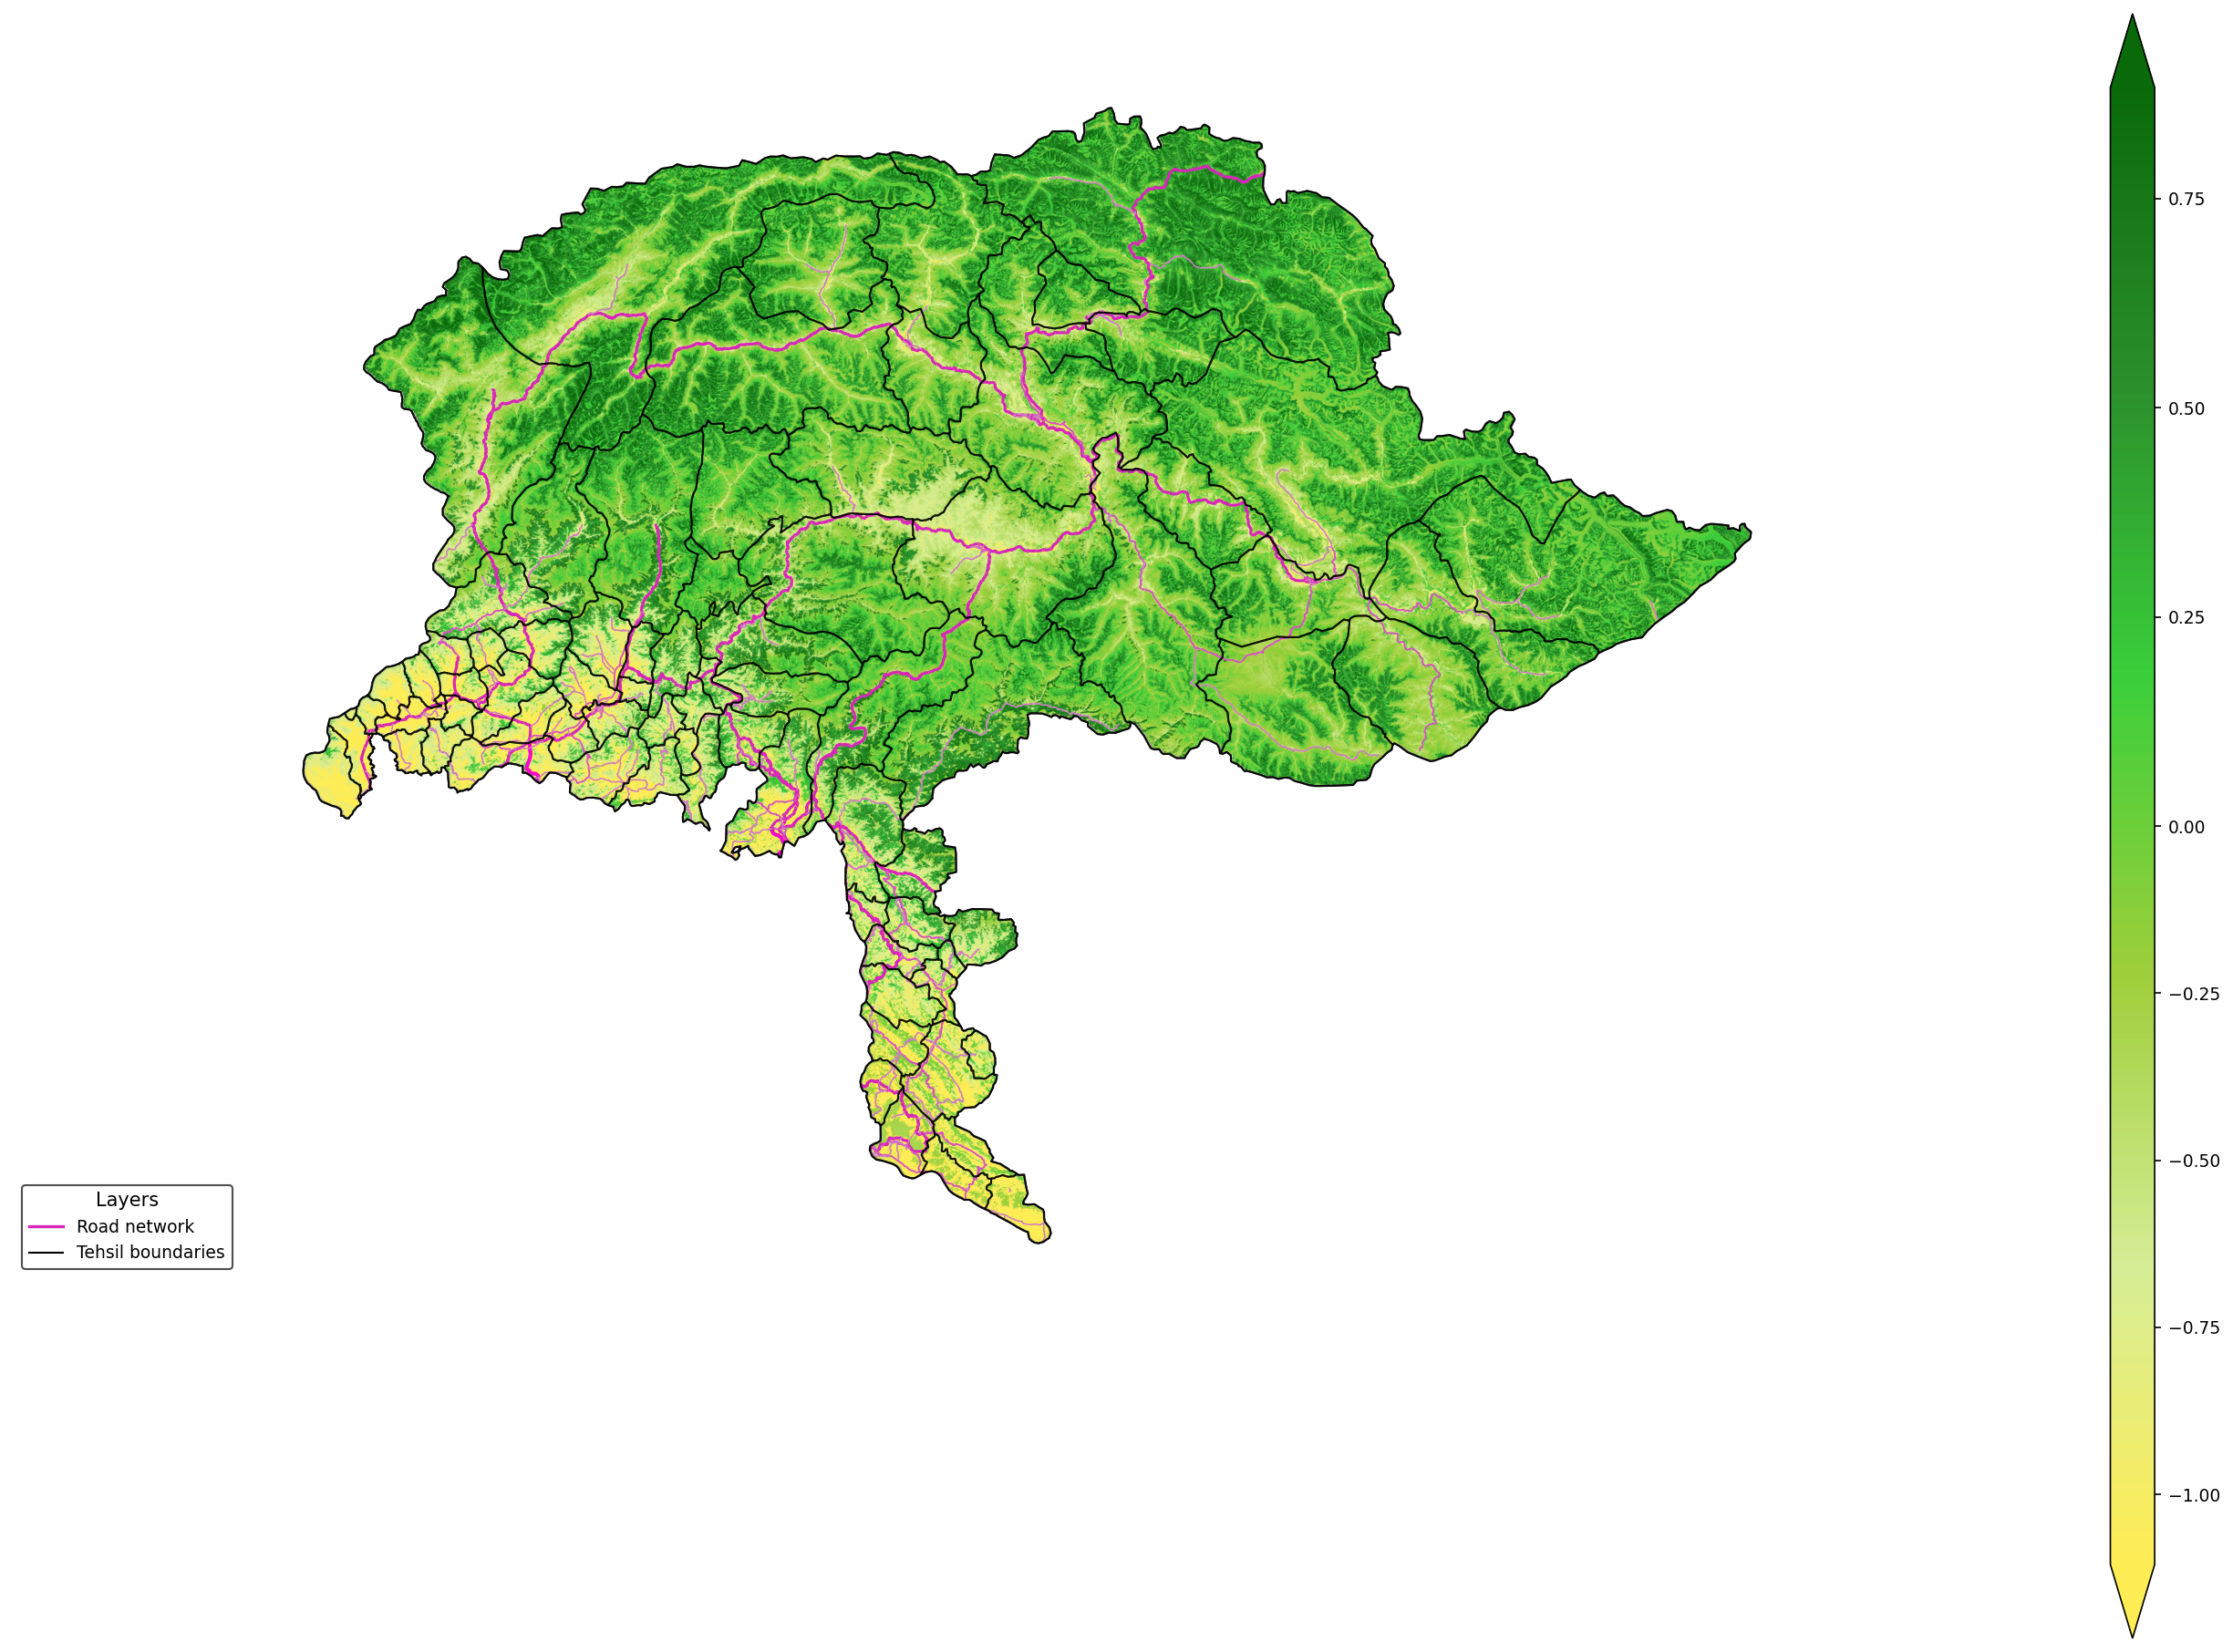

In [69]:
fig, ax = plt.subplots(
    figsize=CONFIG['figure']['figsize'],
    dpi=CONFIG['figure']['dpi']
)
fig.patch.set_facecolor(CONFIG['figure']['figure_facecolor'])
ax.set_facecolor(CONFIG['figure']['axes_facecolor'])

im = ax.imshow(
    spi_data,
    extent=extent,
    origin='upper',
    cmap=cmap,
    norm=norm,
    alpha=CONFIG['spi']['alpha'],
    interpolation=CONFIG['spi']['interpolation'],
    zorder=1
)

for hw_class, style in CONFIG['roads']['style'].items():
    subset = roads[roads['highway'] == hw_class]
    if len(subset):
        subset.plot(
            ax=ax,
            color=style['color'],
            linewidth=style['lw'],
            alpha=style['alpha'],
            zorder=style['zorder']
        )

tehsils.plot(
    ax=ax,
    facecolor='none',
    edgecolor=CONFIG['tehsil_boundaries']['edgecolor'],
    linewidth=CONFIG['tehsil_boundaries']['linewidth'],
    alpha=CONFIG['tehsil_boundaries']['alpha'],
    zorder=CONFIG['tehsil_boundaries']['zorder']
)

aoi.plot(
    ax=ax,
    facecolor='none',
    edgecolor=CONFIG['aoi_outline']['edgecolor'],
    linewidth=CONFIG['aoi_outline']['linewidth'],
    alpha=CONFIG['aoi_outline']['alpha'],
    zorder=CONFIG['aoi_outline']['zorder']
)

if CONFIG['colorbar']['show']:
    cbar_ax = fig.add_axes(CONFIG['colorbar']['axes'])
    cb = fig.colorbar(im, cax=cbar_ax, extend='both')
    cb.ax.tick_params(
        colors=CONFIG['colorbar']['tick_color'],
        labelsize=CONFIG['colorbar']['tick_labelsize']
    )
    cb.outline.set_edgecolor(CONFIG['colorbar']['outline_color'])

if CONFIG['legend']['show']:
    legend_items = [
        Line2D([0], [0], color=CONFIG['roads']['style']['trunk']['color'], linewidth=1.6, label='Road network'),
        Line2D(
            [0], [0],
            color=CONFIG['tehsil_boundaries']['edgecolor'],
            linewidth=1.0,
            label='Tehsil boundaries'
        ),
    ]
    ax.legend(
        handles=legend_items,
        loc=CONFIG['legend']['location'],
        fontsize=CONFIG['legend']['fontsize'],
        framealpha=CONFIG['legend']['framealpha'],
        facecolor=CONFIG['legend']['facecolor'],
        edgecolor=CONFIG['legend']['edgecolor'],
        title=CONFIG['legend']['title'],
        title_fontsize=CONFIG['legend']['title_fontsize']
    )

ax.set_xlim(
    minx - CONFIG['layout']['xlim_pad_left'] * dx,
    maxx + CONFIG['layout']['xlim_pad_right'] * dx
)
ax.set_ylim(
    miny - CONFIG['layout']['ylim_pad_bottom'] * dy,
    maxy + CONFIG['layout']['ylim_pad_top'] * dy
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
for spine in ax.spines.values():
    spine.set_visible(False)

if CONFIG['figure']['show_title']:
    ax.set_title(
        CONFIG['figure']['title'],
        fontsize=CONFIG['figure']['title_fontsize'],
        pad=CONFIG['figure']['title_pad'],
        color='black',
        fontweight='bold'
    )

plt.tight_layout(rect=CONFIG['layout']['tight_layout_rect'])
fig.savefig(
    CONFIG['paths']['output_png'],
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
print(f"Map saved -> {CONFIG['paths']['output_png']}")
plt.show()
